<a href="https://colab.research.google.com/github/AI4ChemS/CHE1147/blob/main/solutions/solutions_tut_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AI4ChemS/CHE1147/blob/main/solutions/solutions_tut_4.ipynb)

# Supervised Learning Workflow

> **Solutions through Section 3 (Baselines).** Exercises from Section 4 onward are left for you to complete.


## Machine learning for discovery of MOFs for gas separation applications

In this notebook we will build machine learning models that can predict the gas uptake (carbon dioxide and methane) of metal-organic frameworks (MOFs), which are crystalline materials consisting of inorganic metal nodes linked by organic linkers. The discovery of MOFs for carbon capture is needed for emission reduction technologies, as these materials can efficiently adsorb and store greenhouse gases like CO$_2$. Machine learning accelerates this discovery process by enabling the prediction of gas uptake properties from structural and chemical descriptors, reducing the need for time-consuming and costly experiments or simulations.

![MOF building principle](../assets/mof_building_principle.png)

There are two main **learning goals** for our tutorial:

1. Understand the typical workflow for machine learning in chemistry and materials. We will cover exploratory data analysis (EDA) and supervised learning (KRR).

2. Get familiar with some Python packages that are useful for data analysis and visualization.

At the end of the exercise, you will produce plot like the one below, comparing the predictions of your model against computed values from GCMC simulations.
The histograms show the distributions of the errors on the training set (left) and on the test set (right).



<img src="../assets/result.gif" alt="Parity interactive" width="700"/>

We will be using scikit-learn for modeling. The [sklearn documentation](https://scikit-learn.org/stable/user_guide.html) is a great source of reference with many explanations and examples. Also, we use Pandas dataframe (df) for data manipulation. You can select columns using their name by running `df[columnname]`. If at any point you think that the dataset is too large for your computer, you can select a subset using `df.sample()` or by making the test set larger in the train/test split (section 2).

> **Credit:** This notebook is adapted from our (Mohamad Moosavi and Kevin Jablonka) lecture and hands-on session in MolSim winter school in Amsterdam.
> - [MolSim](https://www.compchem.nl/molsim/) course website.
> - [kjappelbaum/ml_molsim](https://github.com/kjappelbaum/ml_molsim) on GitHub.

## 0. Setup programming environment

### 0.1 Installing packages

If you are running this notebook locally after cloning [UofT-CHE1147](https://github.com/AI4ChemS/CHE1147) repo, simply install the conda environment

```python
conda env create -f environment.yml
conda activate che1147
```

If you are running this notebook on Google Colab, please uncomment the lines below (remove the `#`) and execute the cell.

In [52]:
# import os, sys, urllib.request

# !pip install -r https://github.com/AI4ChemS/CHE1147/raw/refs/heads/main/requirements_colab.txt

# CHE1147_DIR = "/content/che1147_files"
# os.makedirs(CHE1147_DIR, exist_ok=True)
# data_URL = "https://github.com/AI4ChemS/CHE1147/raw/refs/heads/main/data/MOF_CoRE2019.csv"
# descriptors_URL = "https://github.com/AI4ChemS/CHE1147/raw/refs/heads/main/tutorials/MOF_descriptors.py"

# local_descriptor_path = os.path.join(CHE1147_DIR, "MOF_descriptors.py")
# urllib.request.urlretrieve(descriptors_URL, local_descriptor_path)

# local_data_path = os.path.join(CHE1147_DIR, "MOF_CoRE2019.csv")
# urllib.request.urlretrieve(data_URL, os.path.join(CHE1147_DIR, "MOF_CoRE2019.csv"))

# if CHE1147_DIR not in sys.path:
#     sys.path.append(CHE1147_DIR)


### 0.2 Import packages we will need

> Note, if you are using colab, you may need to install some of the packages.

In [53]:
# basics

import sys
from pathlib import Path

sys.path.insert(0, str(Path("../tutorials").resolve()))

import os
import numpy as np
import pprint as pp

# pandas is used to read/process data
import pandas as pd
from ydata_profiling import ProfileReport

# machine learning dependencies
# scaling of data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# train/test split
from sklearn.model_selection import train_test_split
# model selection
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# the KRR model
from sklearn.kernel_ridge import KernelRidge
# linear model
from sklearn.linear_model import LinearRegression, SGDRegressor
# pipeline to streamline modeling pipelines
from sklearn.pipeline import Pipeline
# principal component analysis
from sklearn.decomposition import PCA
# polynomial kernel
from sklearn.metrics.pairwise import polynomial_kernel
# Dummy model as baseline
from sklearn.dummy import DummyClassifier, DummyRegressor
# Variance Threshold for feature selection
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
# metrics to measure model performance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_absolute_error, mean_squared_error, max_error, mean_absolute_percentage_error)

# save/load models
import joblib

# For the permutation importance implementation
from joblib import Parallel
from joblib import delayed
from sklearn.metrics import check_scoring
from sklearn.utils import Bunch
from sklearn.utils import check_random_state
from sklearn.utils import check_array

# plotting
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### 0.3 Fix the random seed

In [54]:
RANDOM_SEED = 43
np.random.seed(RANDOM_SEED)

 $\color{Aqua}{\textsf{Short question}}$
- We declared a global variable to fix the random seed (`RANDOM_SEED`). Why did we do this?  

### 0.4 Import the data

The dataset used in this tutorial originates from the publication ["Understanding the diversity of the metal-organic framework ecosystem"](https://doi.org/10.1038/s41467-020-17755-8), which explores the application of machine learning for predicting gas adsorption properties in MOFs. This dataset contains geometric and chemical descriptors, as well as simulated gas uptake values, enabling the development and evaluation of regression models for materials discovery.

In [55]:
# load data locally

running_in_colab = 'google.colab' in str(get_ipython())

if running_in_colab:
    DATA_DIR = "/content/che1147_files"
    DATA_FILE = os.path.join(DATA_DIR, "MOF_CoRE2019.csv")
else:
    DATA_DIR = "../data"
    DATA_FILE = os.path.join(DATA_DIR, "MOF_CoRE2019.csv")

try:
    df = pd.read_csv(DATA_FILE)
    print(f"✅ Loaded data from {DATA_FILE}, shape = {df.shape}")

except FileNotFoundError:
    # Fallback: try to load from GitHub raw URL
    url = "https://github.com/AI4ChemS/CHE1147/raw/refs/heads/main/data/MOF_CoRE2019.csv"
    try:
        df = pd.read_csv(url)
        print(f"🌐 Loaded data from GitHub, shape = {df.shape}")
    except Exception as e:
        print(f"❌ Could not find {DATA_FILE} locally or on GitHub.")
        raise e

✅ Loaded data from ../data/MOF_CoRE2019.csv, shape = (5014, 331)


Let's take a look at the first few rows to see if everythings seems reasonable ...

In [56]:
df.head()

,MOFname,ASA [m^2/cm^3],Df,Di,Dif,NASA [m^2/cm^3],POAV [cm^3/g],POAVF,PONAV [cm^3/g],PONAVF,...,sum-f-lig-T-2,sum-f-lig-T-3,sum-f-lig-S-0,sum-f-lig-S-1,sum-f-lig-S-2,sum-f-lig-S-3,CO2 uptake at 0.15 bar and 298K,CO2 uptake at 16 bar and 298K,CH4 uptake at 5.8 bar and 298K,CH4 uptake at 65 bar and 298K
0,XAGCUE_clean,0.00,2.87682,6.41175,6.41175,487.410,0.000000,0.0000,0.101882,0.21558,...,10752.0,10752.0,242.0856,523.7232,844.9008,1049.6448,1.266370,3.120211,1.810078,2.173372
1,SOBZEQ_clean,2298.52,5.44324,7.06044,7.04565,0.000,0.738273,0.6363,0.000000,0.00000,...,2240.0,2544.0,58.2840,130.2840,194.2144,231.0000,8.224130,17.486748,4.560643,11.578465
2,AVAQIX01_clean,0.00,3.61603,5.36267,5.34980,600.353,0.000000,0.0000,0.226377,0.30062,...,3040.0,2688.0,91.7328,204.2656,276.2848,265.7760,3.694178,5.849020,3.859973,5.251466
3,INURIS_clean,0.00,3.09799,5.07769,4.57779,253.440,0.000000,0.0000,0.077296,0.09856,...,12720.0,13728.0,301.4544,713.6976,1037.0160,1127.9280,1.007227,4.092395,2.032925,3.728986
4,KEDNOY_clean,0.00,3.63243,4.98967,4.98020,519.714,0.000000,0.0000,0.238159,0.28890,...,2064.0,1920.0,72.0852,153.0144,199.7088,218.5200,3.617103,6.170669,3.924974,4.888655


<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li>Use something like <code>pd.options.display.max_columns=100</code> to adjust how many columns are shown.<code>pd.options.display.max_columns=100</code>  would show at maximum 100 columns. </li>
</ul>
</details>

Let's also get some basic information ...

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5014 entries, 0 to 5013
Columns: 331 entries, MOFname to CH4 uptake at 65 bar and 298K
dtypes: float64(330), object(1)
memory usage: 12.7+ MB


 $\color{Aqua}{\textsf{Short question}}$
- How many materials are in the dataset?
- Which datatypes do we deal with?

### 0.5 Understanding the data

As descriptors we will use pore geometric descriptors, such as density, pore volume, etc. and [revised autocorrelation functions](https://www.nature.com/articles/s41467-020-17755-8) (RACs) for describing chemistry of MOFs. Our dataset has four properties for MOFs:
- CO2 uptake at 0.15 bar and 298K
- CO2 uptake at 16 bar and 298K
- CH4 uptake at 5.8 bar and 298K
- CH4 uptake at 65 bar and 298K


Let's start with a simple one that is the high-pressure CO$_2$ uptake `df["CO2 uptake at 16 bar and 298K"]`. This is the amount of CO$_2$ (mmol) the MOF can load per gram.

Below, we define three global variables (hence upper case), which are the *names* of our feature and target columns. We will use the `TARGET` for the actual regression and the `TARGET_BINARY` only for the stratified train/test split. The `FEATURES` variable is a list of column names of our dataframe. We imported the names of descriptors from `MOF_descriptors.py`.

In [58]:
# name of descriptors
from MOF_descriptors import geometric_descriptors, linker_descriptors, metalcenter_descriptors, functionalgroup_descriptors, summed_linker_descriptors, summed_metalcenter_descriptors, summed_functionalgroup_descriptors

TARGET = "CO2 uptake at 16 bar and 298K"
FEATURES = (
    geometric_descriptors
    + summed_functionalgroup_descriptors
    + summed_linker_descriptors
    + summed_metalcenter_descriptors
)

Examples for pore geometry descriptors (in `geometric_descriptors`) include: $D_i$ (the size of the largest included sphere), $D_f$ (the largest free sphere), and $D_{if}$ (the largest included free sphere) along the pore $-$ three ways of characterizing pore size.

![pore diameters](../assets/spheres.png)

Also included are the surface area (SA) of the pore, and the probe-occupiable pore volume (POV).
More details on the description of pore geometries can be found in [Ongari et al.](https://pubs.acs.org/doi/abs/10.1021/acs.langmuir.7b01682)

RACs (in the lists starting with `summed_...`) operate on the structure graph and encode information about the metal center, linkers and the functional groups as differences or products of heuristics that are relevant for inorganic chemistry, such as electronegativity ($\chi$), connectivity ($T$), identity ($I$), covalent radii ($S$), and nuclear charge ($Z$).


<img src="../assets/racs.png" alt="RACs scheme from the lecture" width="700"/>

The number in the descriptornames shows the coordination shell that was considered in the calculation of the RACs.

### 0.6 Basic Data Cleaning and Preparation

We perform some data cleaning by removing instances with missing value and removing duplicates.

 $\color{Aqua}{\textsf{Short question}}$
- We we identify a missing value, should we remove that cell, the column or the row with missing value?

In [59]:
num_rows_with_nan = df.isna().any(axis=1).sum()
print(f"Number of rows with NaN values: {num_rows_with_nan}")

Number of rows with NaN values: 1


Write a code to remove the NaN:

In [60]:
df = df.dropna()

Next, we should remove duplicate rows, ensuring dataset contains only unique samples.

In [61]:
# Count and remove duplicate rows
num_duplicates = df.duplicated().sum() # df.duplicated() returns a boolean series with True for each duplicated row, and .sum() counts the number of True values
df = df.drop_duplicates()

print(f"Number of duplicate rows removed: {num_duplicates}")

Number of duplicate rows removed: 14


 $\color{Aqua}{\textsf{Short question}}$
- How many duplicated entries did we remove?

## 1. Split the data

As the first step, we split our data into a training set and a test set. In order to prevent *any* information of the test set from leaking into our model, we split *before* starting to analyze or transform our data.
> **Note:** Not doing the split at this stage can cause data leakage.

## 1.1 Random splitting

A common way of splitting data is random splitting. We can use `sklearn's train_test_split` for doing this.

Depending on the size of the dataset, we might have different splitting ratio. Common split rations are:
- **80/20 Split**: 80% for training, 20% for testing.
- **Train/Validation/Test Split**: For larger datasets, a common split is 70% training, 15% validation, and 15% testing.

In [62]:
df_train, df_test = train_test_split(
    df,
    test_size=0.2,  # 20% for testing
    random_state=RANDOM_SEED  # Ensure reproducibility
)

### 1.1. Split with stratification

Random splitting may lead to imbalanced class distributions between training and test sets, which can result in biased model evaluation and poor generalization.
[Stratification](https://en.wikipedia.org/wiki/Stratified_sampling) ensures that the class distributions (ratio of "good" to "bad" materials) are the same in the training and test set.

 $\color{Aqua}{\textsf{Short question}}$

- Why is this important? What could happen if we would not do this?

### A:
The model may receieve too few examples of one class, and not be able to learn it well!

Ex: A test set with almost no good materials could give high accuracy to a model that only predicts bad for every material

For stratification to work, we to define what makes a "good" or a "bad" material. This requires knowing the target property of interest. Let's start with developing a model for a simple target, which is CO2 uptake at room temperature and high pressure (16bar).

 $\color{Aqua}{\textsf{Short question}}$
- How can we choose a good value to for classifying "good" and "bad" materials?  

<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    You can choose it based on the histogram of the property of interest.
</ul>
</details>

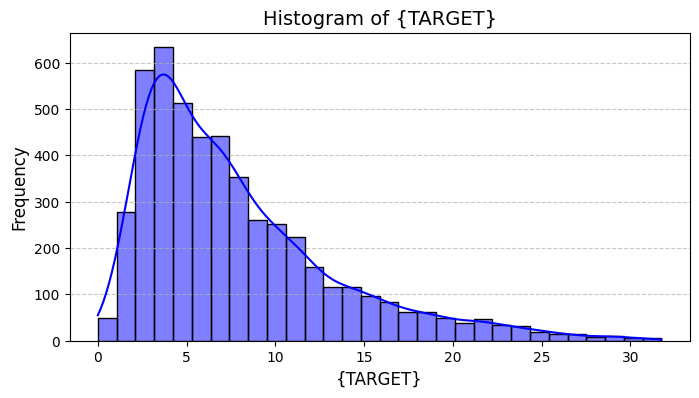

In [63]:
# Plot histogram of the target
plt.figure(figsize=(8, 4))
sns.histplot(df[TARGET], kde=True, bins=30, color='blue')

# Add labels and title
plt.xlabel("{TARGET}", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Histogram of {TARGET}", fontsize=14)

# Show the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Based on this histogram and the tail of the distribution, we will use 15 mmol CO$_2$ / g as the threshold for the uptake, thus binarizing our continuous target variable. We use this threshold to define a new column with binary values of 0 and 1 for bad and good materials.

 $\color{Aqua}{\textsf{Short question}}$
 - add a column 'target_binary' that encodes whether a material is low performing (`0`) or high perfoming (`1`) by comparing the uptake with the `THRESHOLD`

<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li> you can use <a href='https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html'>pd.cut</a>,
    <a href='https://stackoverflow.com/questions/4406389/if-else-in-a-list-comprehension'>list comprehension</a>, the <a href='https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.Binarizer.html#sklearn.preprocessing.Binarizer'> binarizer in sklearn </a>...) </li>
    <li> a list comprehension example: <code> [1 if value > THRESHOLD else 0 for value in df[TARGET]] </code> </li>
</ul>
</details>

In [64]:
TARGET_BINARY = "target_binned" # name of the new binary target column
THRESHOLD = df[TARGET].quantile(0.9)  # Top 10% of the dataset (could also just put 15 here)
df[TARGET_BINARY] = (df[TARGET] > THRESHOLD).astype(int)

Now, we can perform the actual split into training and test set using stratified sampling.

 $\color{Aqua}{\textsf{Short question}}$
- select reasonable values for `XX` and `XY` and then perform the test/train splits. What do you consider when making this decision (think about what you would do with really small and really big datasets, what happens if you have only one test point, what happens to the model performance if you have more test points than training points)?
- why do we need to perform the split into a training and test set?
- would we use the test set to tune the hyperparameters of our model?

<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li>The `size` arguments can either be integers or, often more convenient, decimals like 0.1</li>
    <li>When you perform the split into training and test set you need to trade-off bias (pessimistic bias due to little training data) and variance (due to little test data) </li>
    <li>A typical split cloud be 70/30, but for huge dataset the test set might be too big and for small datasets the training set might be too small in this way </li>
</ul>
</details>

In [65]:
df_train_stratified, df_test_stratified = train_test_split(
    df,
    train_size=0.8,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify= df[TARGET_BINARY]
)

Check if splitting is reasonable:

In [66]:
df_train_stratified.head()

,MOFname,ASA [m^2/cm^3],Df,Di,Dif,NASA [m^2/cm^3],POAV [cm^3/g],POAVF,PONAV [cm^3/g],PONAVF,...,sum-f-lig-T-3,sum-f-lig-S-0,sum-f-lig-S-1,sum-f-lig-S-2,sum-f-lig-S-3,CO2 uptake at 0.15 bar and 298K,CO2 uptake at 16 bar and 298K,CH4 uptake at 5.8 bar and 298K,CH4 uptake at 65 bar and 298K,target_binned
3825,QOBPEE_clean,923.147,5.18460,5.93944,5.93944,0.000,0.179418,0.30118,0.000000,0.00000,...,24.0,39.6100,76.4456,79.8752,6.4824,1.404345,4.005776,2.469047,3.068250,0
4054,SORQAT_clean,0.000,3.31790,4.48730,4.48730,213.490,0.000000,0.00000,0.068459,0.13380,...,1500.0,53.0464,109.2784,161.6768,191.1228,2.289085,2.944084,1.202730,1.743745,0
4191,DANVAQ_clean,0.000,2.76547,5.88569,5.88569,699.391,0.000000,0.00000,0.194336,0.29512,...,4992.0,174.1224,375.1440,522.7680,533.3520,4.899407,7.729199,2.106905,3.207098,0
501,ILIFOY_clean,641.292,4.36093,5.51379,5.51127,0.000,0.150633,0.26790,0.000000,0.00000,...,720.0,25.1046,51.6054,81.2532,95.7066,0.495787,2.362699,1.725037,2.194085,0
4537,MUPTAU_clean,0.000,3.49014,4.16530,4.16530,198.020,0.000000,0.00000,0.176111,0.22086,...,924.0,44.5152,102.8652,136.8096,101.7852,1.172588,4.948858,2.589107,4.821507,0


In [67]:
df_test_stratified.head()

,MOFname,ASA [m^2/cm^3],Df,Di,Dif,NASA [m^2/cm^3],POAV [cm^3/g],POAVF,PONAV [cm^3/g],PONAVF,...,sum-f-lig-T-3,sum-f-lig-S-0,sum-f-lig-S-1,sum-f-lig-S-2,sum-f-lig-S-3,CO2 uptake at 0.15 bar and 298K,CO2 uptake at 16 bar and 298K,CH4 uptake at 5.8 bar and 298K,CH4 uptake at 65 bar and 298K,target_binned
1029,VECWUX_clean,0.000,3.62986,5.40728,4.72861,475.272,0.000000,0.00000,0.186883,0.22708,...,4560.0,102.5688,231.1744,341.2272,400.8576,1.164596,4.496083,2.103022,3.019023,0
3929,S2052520616002663_xk5028sup1_clean,0.000,2.77033,5.40368,5.40368,627.229,0.000000,0.00000,0.178457,0.24766,...,3000.0,65.4066,163.1304,238.4616,270.0792,1.639856,3.884794,3.070478,3.734335,0
4443,LAWGOG_clean,2175.370,7.93827,15.08050,15.06774,0.000,1.312660,0.77372,0.000000,0.00000,...,1500.0,44.5344,97.5744,138.2688,148.0764,0.256389,22.281379,2.187211,15.366620,1
2393,KOMVIT_clean,720.844,4.58324,5.90535,5.82203,0.000,0.206755,0.22426,0.000000,0.00000,...,2144.0,41.7584,100.9404,153.1448,175.0212,0.919777,5.914348,1.861035,4.508595,0
2278,SUNJER_clean,1165.530,3.79637,4.80272,4.65712,0.000,0.289132,0.41432,0.000000,0.00000,...,750.0,22.2672,48.7872,69.1344,74.0382,4.031952,6.593848,4.046203,6.019528,0


## 2. Exploratory data analysis (EDA)

After we have put the test set aside, we can give the training set a closer look.

## 2.1 ydata profiling

> this part takes long so let's do it at home!

In [68]:
# uncomment to run:

# profile = ProfileReport(df_train_stratified, title="EDA Report", explorative=True)
# profile.to_notebook_iframe()
# profile.to_file("MOF_eda_report.html")

### 2.2 Removing redundant columns

We remove any feature that does not have variance across the dataset to reduce dimensionality.
Write a code below that makes a list of features (`redundant_features`) with zero variance.

In [69]:
# Calculate variance using only the training data
feature_variances = df_train_stratified[FEATURES].var()

# List features with zero variance
redundant_features = feature_variances[feature_variances == 0].index.tolist()

print(f"Features with zero variance: {redundant_features}")

Features with zero variance: ['sum-D_func-chi-0-all', 'sum-D_func-Z-0-all', 'sum-D_func-I-0-all', 'sum-D_func-I-1-all', 'sum-D_func-I-2-all', 'sum-D_func-I-3-all', 'sum-D_func-T-0-all', 'sum-D_func-S-0-all', 'sum-D_func-alpha-0-all', 'sum-D_lc-chi-0-all', 'sum-D_lc-Z-0-all', 'sum-D_lc-I-0-all', 'sum-D_lc-I-1-all', 'sum-D_lc-I-2-all', 'sum-D_lc-I-3-all', 'sum-D_lc-T-0-all', 'sum-D_lc-S-0-all', 'sum-D_lc-alpha-0-all', 'sum-D_mc_CRY-chi-0-all', 'sum-D_mc_CRY-Z-0-all', 'sum-D_mc_CRY-I-0-all', 'sum-D_mc_CRY-I-1-all', 'sum-D_mc_CRY-I-2-all', 'sum-D_mc_CRY-I-3-all', 'sum-D_mc_CRY-T-0-all', 'sum-D_mc_CRY-S-0-all']


In [70]:
# update feature set
print(f"Number of features before: {len(FEATURES)}")
FEATURES = [feature for feature in FEATURES if not feature in redundant_features]
print(f"Number of features after: {len(FEATURES)}")

Number of features before: 164
Number of features after: 138


### 2.3. Correlations

 $\color{Aqua}{\textsf{Short question}}$
- Plot some features against the target property and calculate the Pearson and Spearman correlation coefficient (what is the different between those correlation coefficients?)
- What are the strongest correlations? Did you expect them?
- What can be a problem when features are correlated?
- *Optional:* Do they change if you switch from CO$_2$ uptake at high pressure to low pressure `CO2 uptake at 0.15 bar and 298K`?  Explain your observation.

To get the correlation matrices, you can use the `df.corr(method=)`method on your dataframe (`df`). You might want to calculate not the full correlation matrix but just the correlation of the features with the targets

<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li> To get the correlation with a target, you can use indexing. E.g. <code>df.corr(method='spearman')[TARGET]</code></li>
    <li> use <code>.sort_values()</code> method on the output of `df.corr()` to sort by the value of the correlation coefficient  </li>
    <li> Scatter plot of TARGET vs. one descriptor (e.g., Density) </li>
</ul>
</details>

Top 10 features by absolute Pearson correlation:


,Pearson,Spearman
total_SA_gravimetric,0.935528,0.922541
total_POV_volumetric,0.871245,0.895692
total_SA_volumetric,0.812626,0.869515
density [g/cm^3],-0.766772,-0.862869
total_POV_gravimetric,0.740118,0.940042
Di,0.656276,0.731005
Dif,0.650485,0.727024
Df,0.553670,0.667490
sum-f-lig-T-3,0.297547,0.270217
sum-f-lig-T-2,0.277558,0.251514


Top 10 features by absolute Spearman correlation:


,Pearson,Spearman
total_POV_gravimetric,0.740118,0.940042
total_SA_gravimetric,0.935528,0.922541
total_POV_volumetric,0.871245,0.895692
total_SA_volumetric,0.812626,0.869515
density [g/cm^3],-0.766772,-0.862869
Di,0.656276,0.731005
Dif,0.650485,0.727024
Df,0.553670,0.667490
sum-f-lig-T-3,0.297547,0.270217
sum-f-lig-S-3,0.242547,0.263148


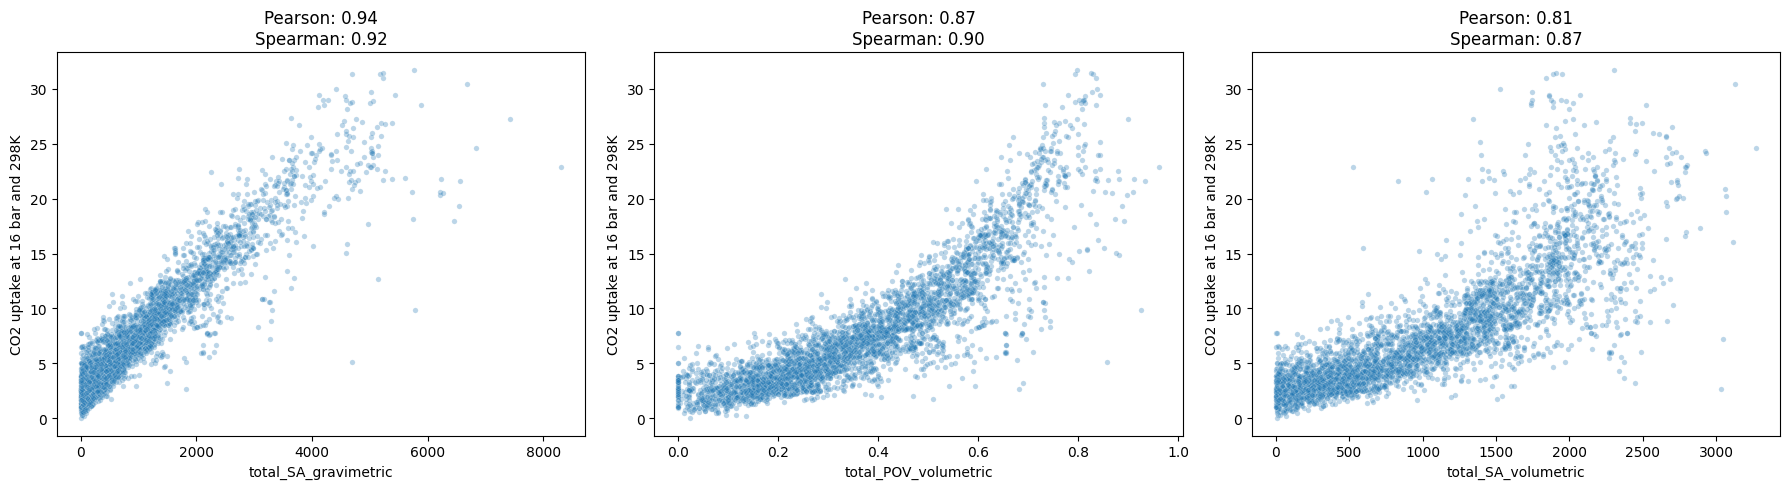

In [71]:
# Calculate the correlation of all features with the target

# Use only training data for exploratory analysis
eda_target = TARGET
# Optional: eda_target = "CO2 uptake at 0.15 bar and 298K"

X = df_train_stratified[FEATURES]
y = df_train_stratified[eda_target]

# Calculate each feature's correlation with the target
correlations = pd.DataFrame({
    "Pearson": X.corrwith(y, method="pearson"),
    "Spearman": X.corrwith(y, method="spearman")
})

# Show the strongest correlations, including negative correlations
for method in ["Pearson", "Spearman"]:
    print(f"Top 10 features by absolute {method} correlation:")
    display(
        correlations.sort_values(
            by=method, key=lambda values: values.abs(), ascending=False
        ).head(10)
    )

# Plot the three features with the strongest Pearson correlations
top_features = correlations["Pearson"].abs().nlargest(3).index

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, top_features):
    sns.scatterplot(
        data=df_train_stratified,
        x=feature,
        y=eda_target,
        alpha=0.3,
        s=15,
        ax=ax
    )
    ax.set_title(
        f"Pearson: {correlations.loc[feature, 'Pearson']:.2f}\n"
        f"Spearman: {correlations.loc[feature, 'Spearman']:.2f}"
    )

plt.tight_layout()
plt.show()


Top 10 features by absolute Pearson correlation:


,Pearson,Spearman
Di,-0.177656,-0.163961
Dif,-0.175305,-0.165091
sum-mc_CRY-chi-2-all,-0.172256,-0.227056
sum-lc-chi-1-all,-0.162843,-0.203090
sum-lc-I-1-all,-0.160021,-0.204096
sum-lc-I-0-all,-0.155274,-0.208418
sum-lc-S-1-all,-0.153713,-0.200063
sum-mc_CRY-chi-0-all,-0.151912,-0.246684
sum-lc-S-0-all,-0.151620,-0.214363
Df,-0.146511,-0.160746


Top 10 features by absolute Spearman correlation:


,Pearson,Spearman
sum-mc_CRY-chi-0-all,-0.151912,-0.246684
sum-mc_CRY-chi-2-all,-0.172256,-0.227056
sum-lc-alpha-0-all,-0.103989,-0.223432
sum-lc-S-0-all,-0.151620,-0.214363
sum-lc-I-0-all,-0.155274,-0.208418
sum-lc-I-1-all,-0.160021,-0.204096
sum-lc-chi-1-all,-0.162843,-0.203090
sum-lc-S-1-all,-0.153713,-0.200063
sum-lc-Z-0-all,-0.111662,-0.191876
sum-lc-alpha-1-all,-0.138992,-0.191549


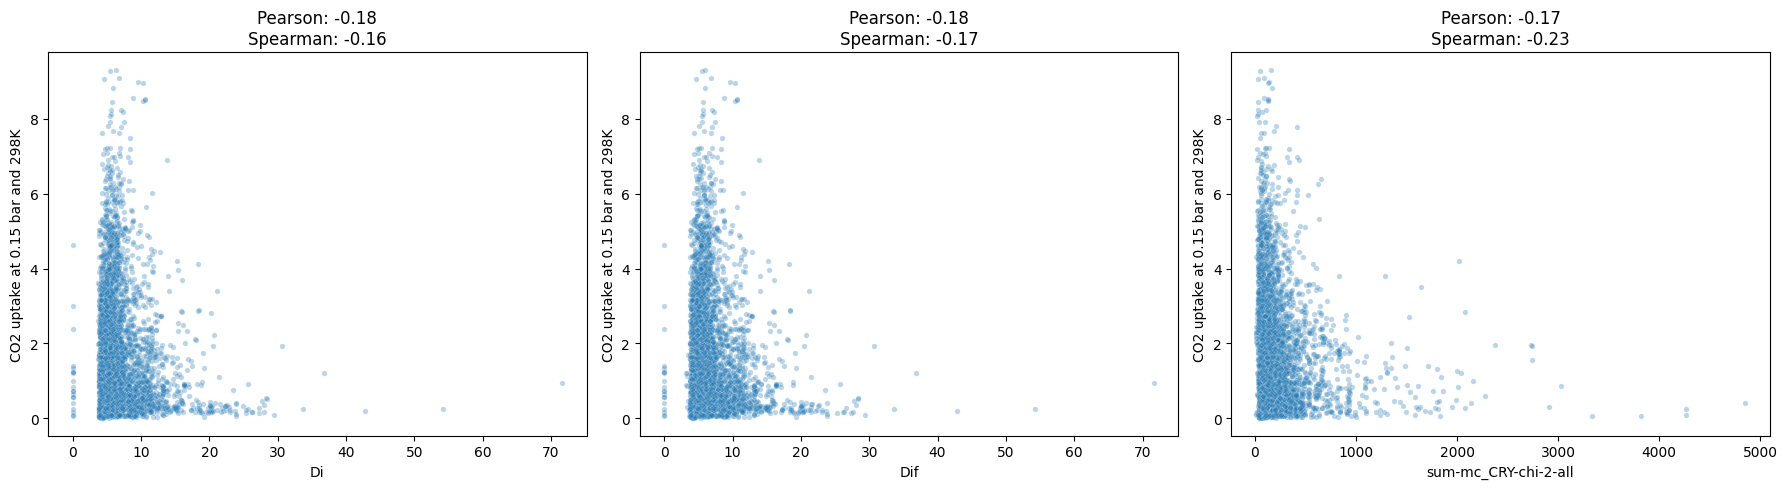

In [72]:
# Repeat the full analysis for low-pressure CO2 uptake
eda_target = "CO2 uptake at 0.15 bar and 298K"

X = df_train_stratified[FEATURES]
y = df_train_stratified[eda_target]

correlations = pd.DataFrame({
    "Pearson": X.corrwith(y, method="pearson"),
    "Spearman": X.corrwith(y, method="spearman")
})

# Show the strongest correlations
for method in ["Pearson", "Spearman"]:
    print(f"Top 10 features by absolute {method} correlation:")
    display(
        correlations.sort_values(
            by=method, key=lambda values: values.abs(), ascending=False
        ).head(10)
    )

# Plot the three strongest features for low-pressure uptake
top_features = correlations["Pearson"].abs().nlargest(3).index

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, top_features):
    sns.scatterplot(
        data=df_train_stratified,
        x=feature,
        y=eda_target,
        alpha=0.3,
        s=15,
        ax=ax
    )
    ax.set_title(
        f"Pearson: {correlations.loc[feature, 'Pearson']:.2f}\n"
        f"Spearman: {correlations.loc[feature, 'Spearman']:.2f}"
    )

plt.tight_layout()
plt.show()

## 3. Baselines

For machine learning, it is important to have some *baselines* to which one then compares the results of a model. Think of a classification model for some rare disease where we only have 1% postives. A classification model that only predictes the negatives *all the time* will still have a amazingly high accuracy. To be able to understand if our model is really better than such a simple prediction we need to make the simple prediction first. This is what we call a baseline.

A baseline could be a really simple model, a basic heuristic or the current state of the art (SOTA).
this. We will use a heuristic but if you aim for a publication, a baseline for you will be the state of the art model.

For this we use sklearn `Dummy` objects that simply calculate the mean, the median or the most frequent case of the training set, when you run the `fit()` method on them (which takes the features matrix $\mathbf{X}$ and the labels $\mathbf{y}$ as arguments.
This is, the prediction of a `DummyRegressor` with `mean` strategy will always be the mean, independent of the input (it will not look at the feature matrix!).

Instead of using those `sklearn` objects you could also just manually compute the the mean or median of the dataset. But we will use those objects as we can learn in this way how to use estimators in `sklearn` and it is also allows you to test your full pipeline with different (baseline) models.
What does this mean? In practice this means that you can use all the regression and classification models shown in the figure below in the same way, they will all have a `fit()` method that accepts `X` and `y` and a predict method that accepts `X` and returns the predictions.


<img src="https://scikit-learn.org/1.3/_static/ml_map.png" alt="ML Map" width="800"/>

The estimator objects can be always used in the same way

<img src="https://static.packt-cdn.com/products/9781789800265/graphics/d49a2e95-8f22-42ed-89f1-474b3d028787.png" alt="ML Map" width="400"/>

Using these objects, instead of the mean directly, allows you to easily swap them with other models in pipelines, where one chains many data transformation steps (see section 6).

### 3.1. Build dummy models

 $\color{Aqua}{\textsf{Short question}}$
- If you call `.fit(X, y)` on a `DummyRegressor` does it actually use the `X`? If not, why is there still the place for the `X` in the function? If yes, how does it use it?

 $\color{Aqua}{\textsf{Short question}}$
- Create [`DummyRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html) instances for  `mean`, `median`. (e.g. `dummyinstance = DummyRegressor(strategy='mean')`)
- Train them on the training data (`dummyinstance.fit(df_train[FEATURES], df_train[TARGET])`)

<details>
<summary> <font color='green'>Click here for hints</font></summary>
<ul>
    <li> to create <code>DummyRegressor</code> you can for example use <code> dummyregressor_mean = DummyRegressor(strategy='mean') </code> </li>
    <li> to see the implementation of the <code>DummyRegressor</code> you can check out <a href="https://github.com/scikit-learn/scikit-learn/blob/73732e5a0bc9b72c7049dc699d69aaedbb70ef0a/sklearn/dummy.py#L391"> the source code on GitHub</a> </li>
</ul>
</details>

In [73]:
# Build DummyRegressors
dummyregressor_mean = DummyRegressor(strategy='mean')
dummyregressor_median = DummyRegressor(strategy='median')

In [74]:
# Fit Dummy Regressors
dummyregressor_mean.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])
dummyregressor_median.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])

,strategy,'median'
,constant,None
,quantile,None


#### Evaluate the performance of the dummy models

 $\color{Aqua}{\textsf{Short questions}}$
- Calculate maximum error, mean absolute error and mean square error for the dummy regressors on training and test set. What would you expect those numbers to be?
- Do the actual values surprise you?
- What does this mean in practice for reporting of metrics/the reasoning behind using baseline models

It can be handy to store our metrics of choice in a nested dictionary ([Python dictionaries are key-value pairs](https://www.tutorialspoint.com/python/python_dictionary.htm)):

```python
{
    'dummyestimator1': {
                        'metric_a_key': metric_a_value,
                        'metric_b_key': metric_b_value
                    },
    'dummyestimator2': {
                        'metric_a_key': metric_a_value,
                        'metric_b_key': metric_b_value
                    },
 }
```

You will now write functions `get_regression_metrics(model, X, y_true)` that compute the metrics and return this dictionary for a given model. The `predict` method takes the feature matrix $\mathbf{X}$ as input.

In them, we calculate

$\mathrm {MAE} =\frac{\sum _{i=1}^{n}\left|Y_{i}-\hat{y}_{i}\right|}{n}.$

,

$\mathrm {MSE} = {\frac {1}{n}}\sum _{i=1}^{n}(Y_{i}-{\hat {Y_{i}}})^{2}.$

$\mathrm{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{Y_i - \hat{Y}_i}{max (\epsilon,Y_i)} \right|$

where $\hat{y}$ are the predictions and, $Y_{i}$ the true values.

We also include maximum error which is a good indication for generalization in many cases.

See more information on [sklearn's Metrics and scoring: quantifying the quality of predictions](https://scikit-learn.org/stable/modules/model_evaluation.html#mean-absolute-percentage-error)



<details>
<summary> <font color='green'>Click here for hints</font></summary>
<ul>
    <li> to perform a prediction using a estimator object, you can call <code> classifier.predict(X) </code> </li>
    <li> to calculate metrics, you can for example call <code>accuracy_score(true_values, predicted_values) </code> </li>
</ul>
</details>

In [75]:
def get_regression_metrics(model, X, y_true):
    """
    Get a dicionary with regression metrics:

    model: sklearn model with predict method
    X: feature matrix
    y_true: ground truth labels
    """
    y_predicted = model.predict(X)

    mae = mean_absolute_error(y_true, y_predicted)
    mse = mean_squared_error(y_true, y_predicted)
    maximum_error = max_error(y_true, y_predicted)
    mape = mean_absolute_percentage_error(y_true, y_predicted)

    metrics_dict = {
        'mae': mae,
        'mse': mse,
        'max_error': maximum_error,
        'mape': mape
    }

    return metrics_dict

In [76]:
dummy_regressors = [
    ('mean', dummyregressor_mean),
    ('median', dummyregressor_median)
]

In [77]:
dummy_regressor_results_test = {} # initialize empty dictionary
dummy_regressor_results_train = {}

# loop over the dummy_regressor list
# if you have a tuple regressorname, regressor = (a, b) that is automatically expanded into the variables
# a = regressorname, b = regressor
for regressorname, regressor in dummy_regressors:
    print(f"Calculating metrics for {regressorname}")
    dummy_regressor_results_test[regressorname] = get_regression_metrics(regressor, df_test[FEATURES], df_test[TARGET])
    dummy_regressor_results_train[regressorname] = get_regression_metrics(regressor, df_train[FEATURES], df_train[TARGET])

Calculating metrics for mean
Calculating metrics for median


In [78]:
print("Dummy Regressor Results - Train & Test Set")

for regressorname, metrics in dummy_regressor_results_train.items():
    print(f"{regressorname} (Train): {metrics}")

for regressorname, metrics in dummy_regressor_results_test.items():
    print(f"{regressorname} (Test): {metrics}")


Dummy Regressor Results - Train & Test Set
mean (Train): {'mae': 4.239731904698775, 'mse': 30.58928402402038, 'max_error': 23.906875359345236, 'mape': 0.9349442182448595}
median (Train): {'mae': 4.046418013256864, 'mse': 32.69934512454708, 'max_error': 25.407251010299998, 'mape': 0.7333289563093786}
mean (Test): {'mae': 4.291179634244424, 'mse': 30.59375717687806, 'max_error': 23.474331665845238, 'mape': 7.560984248265951}
median (Test): {'mae': 4.1512562783160005, 'mse': 33.236222527738036, 'max_error': 24.9747073168, 'mape': 6.100087197581229}


## 4. Building a linear regression model

In practice, we often rely on optimized libraries such as **scikit-learn** for machine learning models.  
They are fast, robust, and widely used.  

However, to really understand *what happens under the hood*, it is useful to **implement a simple linear regression model ourselves**.  

### Goals for this section:
- Implement **gradient descent** for linear regression.
- Compare results between **gradient descent** and the **closed-form (normal equation)** solution.
- Use **scikit-learn**'s `LinearRegression` as a baseline for comparison.


### 4.1 sklearn linear regression

Let's first use the sklearn model to get a good baseline for comparison.
You can see with few lines below, we can train a machine learning model.
The code is very flexible and you can essentially replace the linear regression with other models in sklearn.

Write the code below to train and evaluate a linear regression model using sklearn's `LinearRegression` class.

In [ ]:
# Initialize the Linear Regression model
linear_regressor = LinearRegression()

# Train the model on the training data
# FILLME

# Evaluate the model on the training and test sets
# FILLME

# Print the results
print("Linear Regression Results - Train Set:", linear_regressor_results_train)
print("Linear Regression Results - Test Set:", linear_regressor_results_test)

### 4.1 Linear regression from scratch

Now, let's code a linear regression to see if we understand all parts. Specifically, we are going to code the gradient descent for our regressor to fit its parameters.

The class below supports:
- `method="normal"`: closed-form solution using the normal equation  
- `method="gd"`: gradient descent with configurable learning rate and iterations  
- Optional standardization of features for smoother optimization  


Code the missing part in the gradient descent.

In [ ]:
class MyLinearRegression:
    def __init__(self, fit_intercept=True, standardize=False, method="normal",
                 lr=1e-2, n_iters=100, tol=1e-8, random_state=0):
        """
        method: "normal" (closed-form) or "gd" (gradient descent, MSE loss)
        """
        self.fit_intercept = fit_intercept
        self.standardize = standardize
        self.method = method
        self.lr = lr
        self.n_iters = n_iters
        self.tol = tol
        self.random_state = random_state
        self.coef_ = None
        self.intercept_ = 0.0
        self._x_mean = None
        self._x_std = None

    def _prepare_X(self, X, fit=False):
        X = np.asarray(X, dtype=float)
        if fit and self.standardize:
            self._x_mean = X.mean(axis=0, keepdims=True)
            self._x_std = X.std(axis=0, keepdims=True)
            self._x_std[self._x_std == 0] = 1.0
        if self.standardize:
            Xs = (X - self._x_mean) / self._x_std
        else:
            Xs = X
        if self.fit_intercept:
            Xs = np.c_[np.ones((Xs.shape[0], 1)), Xs]
        return Xs

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1,)

        Xp = self._prepare_X(X, fit=True)

        # NORMAL EQUATION
        if self.method == "normal":
            # theta = (X^T X)^{-1} X^T y  with ridge-like jitter for stability
            XT_X = Xp.T @ Xp
            # add tiny jitter to diagonal to avoid singular matrix in edge cases
            jitter = 1e-12 * np.eye(XT_X.shape[0])
            theta = np.linalg.pinv(XT_X + jitter) @ (Xp.T @ y)

        # GRADIENT DESCENT
        elif self.method == "gd":
            # Add your code here
            n_features = Xp.shape[1]
            theta = rng.normal(scale=0.01, size=n_features)
            prev_loss = np.inf
            for i in range(self.n_iters):
                y_pred = Xp @ theta
                residuals = y_pred - y
                loss = #FILLME
                if abs(prev_loss - loss) < self.tol:
                    break
                prev_loss = loss
                grad = (Xp.T @ residuals) / len(y)
                theta -= #FILLME
        else:
            raise ValueError("method must be 'normal' or 'gd'")

        # unpack theta into intercept and coefficients
        if self.fit_intercept:
            self.intercept_ = float(theta[0])
            self.coef_ = theta[1:]
        else:
            self.intercept_ = 0.0
            self.coef_ = theta
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        if self.standardize:
            Xs = (X - self._x_mean) / self._x_std
        else:
            Xs = X
        return self.intercept_ + Xs @ self.coef_

In [ ]:
# Initialize two Linear Regression model with different optimization methods
my_linear_regressor_gd = MyLinearRegression(fit_intercept=True, standardize=True, method="gd")
my_linear_regressor_cf = MyLinearRegression(fit_intercept=True, standardize=True, method="normal")

# Train the model on the training data
my_linear_regressor_gd.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])
my_linear_regressor_cf.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])

# Evaluate the model on the training and test sets
my_linear_regressor_gd_results_test = get_regression_metrics(
    my_linear_regressor_gd, df_train_stratified[FEATURES], df_train_stratified[TARGET]
)
my_linear_regressor_cf_results_test = get_regression_metrics(
    my_linear_regressor_cf, df_test_stratified[FEATURES], df_test_stratified[TARGET]
)

In [ ]:
# comparing results
print("Linear Regression Results - sklearn:", linear_regressor_results_test)
print("Linear Regression Results - cf:", my_linear_regressor_cf_results_test)
print("Linear Regression Results - gd:", my_linear_regressor_gd_results_test)


We can see how gradient descent results would be changing its parameters, namely learning rate and number of iterations.
Use the sliders to change the **learning rate** and the **number of iterations**.  
We’ll refit our custom gd model, plot the **loss vs. iteration**, and print evaluation metrics.

In [ ]:
my_linear_regressor_gd = MyLinearRegression(fit_intercept=True, standardize=True, method="gd",lr=1e-2, n_iters=1000)
my_linear_regressor_gd.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])
my_linear_regressor_gd_results_test = get_regression_metrics(
    my_linear_regressor_gd, df_train_stratified[FEATURES], df_train_stratified[TARGET]
)
print("Linear Regression Results - gd:", my_linear_regressor_gd_results_test)

In [ ]:
from ipywidgets import interact, FloatLogSlider, IntSlider, fixed
from IPython.display import display

def run_gd_and_plot(lr, n_iters, df, FEATURES, TARGET, get_regression_metrics):
    model = MyLinearRegression(
        fit_intercept=True,
        standardize=True,
        method="gd",
        lr=lr,
        n_iters=n_iters,
        tol=1e-12,
        random_state=0
    )
    model.fit(df[FEATURES].values, df[TARGET].values)

    metrics = get_regression_metrics(model, df[FEATURES], df[TARGET])

    plt.figure(figsize=(6,4))
    plt.xlabel("Iteration")
    plt.ylabel("Loss (MSE/2)")
    plt.title(f"lr={lr:.1e}, iters={n_iters}, MAE={metrics['mae']:.2f}, MAPE={metrics['mape']:.2f}")
    plt.plot(df[TARGET].values, model.predict(df[FEATURES].values), 'o', alpha=0.3)
    plt.plot(df[TARGET].values, df[TARGET].values, 'k--', label="y=x")
    plt.xlim(0.95*df[TARGET].min(), 1.05*df[TARGET].max())
    plt.ylim(0.95*df[TARGET].min(), 1.05*df[TARGET].max())
    plt.legend()
    plt.show()

In [ ]:
interact(
    run_gd_and_plot,
    lr=FloatLogSlider(value=1e-4, base=10, min=-5, max=0, step=0.1, description="learning rate"),
    n_iters=IntSlider(value=100, min=10, max=10000, step=50, description="iterations"),
    df=fixed(df_train_stratified),
    FEATURES=fixed(FEATURES),
    TARGET=fixed(TARGET),
    get_regression_metrics=fixed(get_regression_metrics)
)

You can find more information about gradient descent in this paper: [A high-bias, low-variance introduction to Machine Learning for physicists](https://doi.org/10.1016/j.physrep.2019.03.001)

Below is a schematic illustration from the paper showing how learning rate can affect the outcome of optimization.

![Gradient Descent Illustration](../assets/GD_figure.jpg)


$\color{Aqua}{\textsf{Short Exercise}}$
- what happens when the learning rate is too small?
- What about when it is too large?

<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li> Too small leads to extremely slow convergance and too large can lead to overshoot!</li>
</ul>
</details>

## 5. Build a Ridge Regression Model

In [79]:
# ---- Catch-up cell ----
# run the first notebook cells, up to to `0.6`
# and then this cell, which will complete the requiered (#fillme) sections

from MOF_descriptors import (geometric_descriptors, summed_functionalgroup_descriptors,
                             summed_linker_descriptors, summed_metalcenter_descriptors)

TARGET = "CO2 uptake at 16 bar and 298K"
FEATURES = (
    geometric_descriptors
    + summed_functionalgroup_descriptors
    + summed_linker_descriptors
    + summed_metalcenter_descriptors
)

# 0.6 basic data cleaning
df = df.dropna().drop_duplicates().copy()

# 1.1 stratified train/test split
TARGET_BINARY = "target_binned"
THRESHOLD = df[TARGET].quantile(0.9)
df[TARGET_BINARY] = (df[TARGET] > THRESHOLD).astype(int)
df_train_stratified, df_test_stratified = train_test_split(
    df, train_size=0.8, test_size=0.2, random_state=RANDOM_SEED, stratify=df[TARGET_BINARY]
)

# 2.2 remove features with zero variance (on the training set only)
redundant_features = [f for f in FEATURES if df_train_stratified[f].var() == 0]
FEATURES = [f for f in FEATURES if f not in redundant_features]

# 3. make the regression metrics function
def get_regression_metrics(model, X, y_true):
    y_predicted = model.predict(X)
    return {
        'mae': mean_absolute_error(y_true, y_predicted),
        'mse': mean_squared_error(y_true, y_predicted),
        'max_error': max_error(y_true, y_predicted),
        'mape': mean_absolute_percentage_error(y_true, y_predicted),
    }

# 3.1 training dummy baselines and 4.1 linear regression
dummyregressor_mean = DummyRegressor(strategy='mean').fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])
dummyregressor_median = DummyRegressor(strategy='median').fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])
linear_regressor = LinearRegression().fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])

print(f"Training set: {df_train_stratified.shape}, test set: {df_test_stratified.shape}, number of features: {len(FEATURES)}")

Training set: (3999, 332), test set: (1000, 332), number of features: 138


In [80]:
# new tools we will use in this part of the tutorial
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score, validation_curve
from matplotlib.colors import LogNorm

In section 4 we fitted an ordinary least squares linear regression. In the lecture we saw that fitting the training data as well as possible does not mean that the model will generalize well (bias-variance trade-off).

We can control the complexity of a model by adding a penalty term to the loss function. An example is **ridge regression**, which is linear least squares with L2 regularization. The first term rewards fitting the training data, while the second term penalizes large weights:

$$\hat{\phi} = \underset{\phi}{\mathrm{argmin}} \; \|y - X\phi\|^2 + \lambda\|\phi\|^2$$

In the closed form:

$$\hat{\phi}_{\text{ridge}} = (X^\top X + \lambda I)^{-1} X^\top y \qquad \text{vs.} \qquad \hat{\phi}_{\text{OLS}} = (X^\top X)^{-1} X^\top y$$


In sklearn, ridge regression is implemented in [`Ridge`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html), and the regularization strength $\lambda$ is called `alpha`.

Let's build a simple ridge regression model.

In [81]:
# Train a ridge regression model with the default regularization
ridge = Ridge(alpha=1.0)
ridge.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


 $\color{Aqua}{\textsf{Short question}}$
- Do you expect this model to perform better than the dummy models? And better than the linear regression from section 4?
- Use the `get_regression_metrics` function to calculate the performance metrics on the training and test set. How do they compare to the performance of the dummy mean model and of the linear regression?

In [82]:
# get the metrics on the train and the test set using the get_regression_metrics function
# compare with the dummy mean model and the linear regression, all evaluated on the same stratified split
models_to_compare = {
    'dummy (mean)': dummyregressor_mean,
    'linear regression': linear_regressor,
    'ridge (alpha=1)': ridge,
}

# dictionaries to store results
train_results = {}
test_results = {}

# hint: use the function in a loop
for name, m in models_to_compare.items():
    train_results[name] = get_regression_metrics(m, df_train_stratified[FEATURES], df_train_stratified[TARGET])
    test_results[name]  = get_regression_metrics(m, df_test_stratified[FEATURES], df_test_stratified[TARGET])

# results DataFrames and transpose so models are the rows
df_train = pd.DataFrame(train_results).T
df_test = pd.DataFrame(test_results).T

# Concatenate
comparison = pd.concat({
    'train': df_train,
    'test': df_test
}, axis=1)

comparison

train                                      test  \
                        mae        mse  max_error      mape       mae   
dummy (mean)       4.239382  30.392667  23.906875  2.576412  4.292577   
linear regression  1.030220   2.299876  16.393727  0.487657  2.785506   
ridge (alpha=1)    1.036824   2.306009  16.460895  0.452200  2.968310   

                                                       
                           mse    max_error      mape  
dummy (mean)         31.380029    22.435802  0.996755  
linear regression  2685.220372  1637.622683  0.442920  
ridge (alpha=1)    3306.439683  1817.419944  0.463327

## 6. Evaluate the model performance

We have trained our first regularized machine learning model. We'll first have a closer look at its performance by plotting the predictions.

We provide a function that draws the parity plot (true values against predictions) as a 2D histogram.

The color shows the density of MOFs, and the dashed line is a perfect prediction ($y_{pred} = y_{true}$).

This is easier to read than a regular scatter plot when thousands of points overlap. 

<details>
<summary> <font color='green'>Click here for hints for plotting</font></summary>
<ul>
    <li> If you want to use matplotlib to make the parity plots, you can use the <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist2d.html">hist2d function</a> </li>
    <li> To create the frequencies and the edges of a histogram, one can use <code>np.histogram</code></li>
</ul>
</details>

In [83]:
def hist_density(y_true, y_pred, xlabel='y true', ylabel='y pred', title=None, bins=50):
    """Parity plot drawn as a 2D histogram.

    y_true: true values
    y_pred: predicted values
    """
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    mae = np.mean(np.abs(y_true - y_pred))

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    h = ax.hist2d(y_true, y_pred, bins=bins, range=[lims, lims], cmin=1, cmap='viridis', norm=LogNorm())
    fig.colorbar(h[3], ax=ax, label='number of MOFs')
    ax.plot(lims, lims, 'k--', lw=1, label='y = x')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title} (MAE = {mae:.2f})" if title else f"MAE = {mae:.2f}")
    ax.legend(loc='upper left')
    plt.show()

In [84]:
# Create dictionaries with training and test results to create parity plots
res_train = {
    'y true': df_train_stratified[TARGET].values,
    'y pred': ridge.predict(df_train_stratified[FEATURES])
}

res_test = {
    'y true': df_test_stratified[TARGET].values,
    'y pred': ridge.predict(df_test_stratified[FEATURES])
}

Now, plot the parity plots

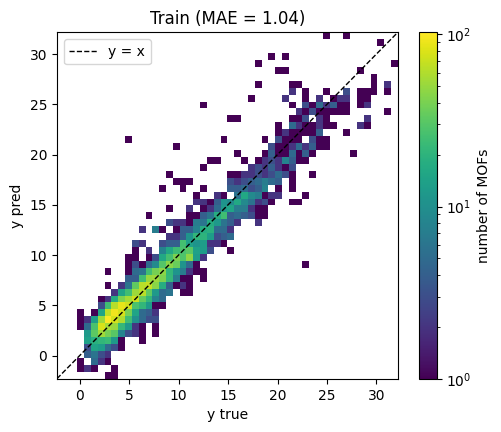

In [85]:
# plot it
hist_density(res_train['y true'], res_train['y pred'], xlabel='y true', ylabel='y pred', title='Train')

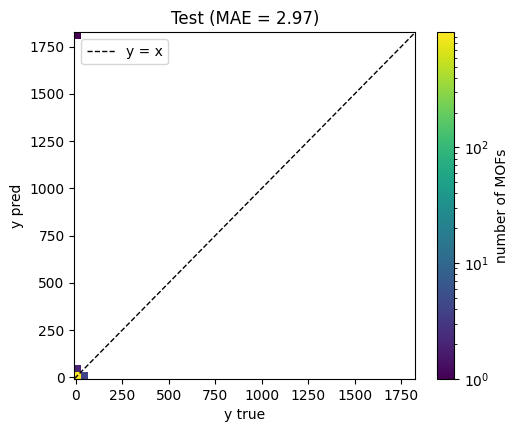

In [86]:
hist_density(res_test['y true'], res_test['y pred'], xlabel='y true', ylabel='y pred', title='Test')

 $\color{Aqua}{\textsf{Short Exercise}}$
- Hypothesize: how will the parity plot for the mean dummy model look?
- Confirm by plotting below using the results for this model

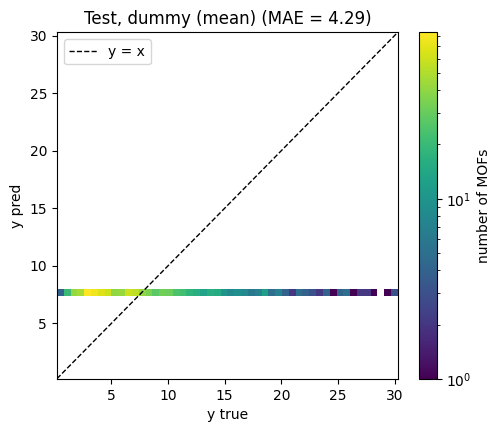

In [87]:
# parity plot of a dummy mean model
hist_density(df_test_stratified[TARGET], dummyregressor_mean.predict(df_test_stratified[FEATURES]),
             xlabel='y true', ylabel='y pred', title='Test, dummy (mean)')

## 7. Improve the model

Our training set still has a couple of issues you might have noticed:
- The feature values are not scaled (different features are measured in different units ...)
- Some features are basically constant, and do not contain relevant information
- Our model is linear, but the relationship between the descriptors and the gas uptake is probably not

### 7.1. Standard scaling and building a first pipeline

We will now go beyond training a single model, we will build [Pipelines](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), which are objects that can collect a selection of transformations and estimators. This makes it quite easy to apply the same set of operations to different datasets.

A pipeline also prevents data leakage: the scaler is fitted on the training data only, and the same transformation is then applied to the test data.

 $\color{Aqua}{\textsf{Short Exercise}}$
- Build a pipeline that first performs standard scaling and then fits a ridge regression model. Call it `pipe_w_scaling`.
- Fit it on the training set.
- Make predictions and make the parity plot.
- Compare the test metrics with the unscaled `ridge` model of section 5. Did scaling change the performance compared to unscaled `Ridge`? Why?

<details>
<summary> <font color='green'>Click here for hints</font></summary>
<ul>
    <li> the <code>fit</code>, <code>predict</code> methods also work for pipelines </li>
</ul>
</details>

In [88]:
pipe_w_scaling = Pipeline(
   [
       ('scaling', StandardScaler()),
       ('ridge', Ridge(alpha=1))
   ]
)

Ridge (scaled) - Train: {'mae': 1.0407662866538232, 'mse': 2.3500707940583196, 'max_error': 16.944392575965573, 'mape': 0.3984207452005447}
Ridge (scaled) - Test:  {'mae': 1.479145044089444, 'mse': 127.76625740946814, 'max_error': 353.006100694257, 'mape': 0.28463750319252507}
Ridge (unscaled)    - Test:  {'mae': 2.968310227420783, 'mse': 3306.43968282054, 'max_error': 1817.4199436978568, 'mape': 0.46332744518606395}


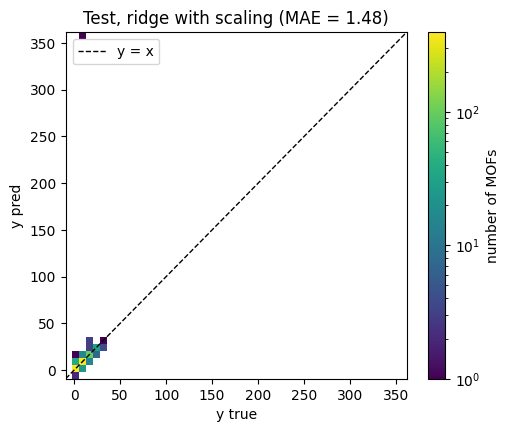

In [89]:
# fit the pipeline, calculate the metrics and make the parity plots
pipe_w_scaling.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])

print("Ridge (scaled) - Train:", get_regression_metrics(pipe_w_scaling, df_train_stratified[FEATURES], df_train_stratified[TARGET]))
print("Ridge (scaled) - Test: ", get_regression_metrics(pipe_w_scaling, df_test_stratified[FEATURES], df_test_stratified[TARGET]))
print("Ridge (unscaled)    - Test: ", get_regression_metrics(ridge, df_test_stratified[FEATURES], df_test_stratified[TARGET]))

hist_density(df_test_stratified[TARGET], pipe_w_scaling.predict(df_test_stratified[FEATURES]), title='Test, ridge with scaling')

### 7.2. Nonlinear regression: mapping the features to a higher dimensional space

So far our model is linear in the features. In the lecture we saw that we can describe nonlinear relationships with a model that is still linear in the parameters by mapping the inputs into a higher dimensional feature space, for example with polynomials:

$$\hat{y} = \phi_0 + \phi_1 x + \phi_2 x^2 + \dots + \phi_p x^p$$

In sklearn, this mapping is done by [`PolynomialFeatures`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html), which we can add as a step to our pipeline.

To see what happens when we increase the model complexity (the polynomial degree $p$), let's do an example similar to the lecture: we will use just ONE descriptor that is most correlated with the target, and a very small training set (30 MOFs). To check how well the models generalize, we use a validation set that we take from the training set. The test set stays untouched.

In [90]:
# the single descriptor that is most correlated with the target
ONE_FEATURE = (
    df_train_stratified[FEATURES]
    .corrwith(df_train_stratified[TARGET], method='spearman')
    .abs()
    .idxmax()
)
print(f"Descriptor: {ONE_FEATURE}")

Descriptor: total_POV_gravimetric


In [91]:
# a small training set (30 MOFs)
df_small = df_train_stratified.sample(n=30, random_state=RANDOM_SEED)
# and a validation set taken from the remaining training data 
df_val_1d = df_train_stratified.drop(df_small.index).sample(n=500, random_state=RANDOM_SEED)

# small datasets with just 1 feature
X_small, y_small = df_small[[ONE_FEATURE]], df_small[TARGET]
X_val_1d, y_val_1d = df_val_1d[[ONE_FEATURE]], df_val_1d[TARGET]

Now we use these functions: 
- `make_poly_model` builds the pipeline for a given degree and regularization strength
-  `plot_1d_fits` plots the fitted curves

In [92]:
def make_poly_model(degree, alpha=1e-8):
    """Pipeline: scaling -> polynomial feature mapping -> scaling -> ridge regression."""
    return Pipeline([
        ('scaling', StandardScaler()), # 1st scaling: so features scales match
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('poly_scaling', StandardScaler()), # 2nd scaling: so polynomial terms are on the same scale
        ('ridge', Ridge(alpha=alpha)),
    ])


def plot_1d_fits(models):
    """Plots each fitted curve with the training and validation data.
    
    Args:
       models: dictionary {label: fitted model}
    """
    x_min = min(X_small[ONE_FEATURE].min(), X_val_1d[ONE_FEATURE].quantile(0.01))
    x_max = max(X_small[ONE_FEATURE].max(), X_val_1d[ONE_FEATURE].quantile(0.99))
    x_grid = pd.DataFrame({ONE_FEATURE: np.linspace(x_min, x_max, 400)})
    y_margin = 0.2 * (y_val_1d.max() - y_val_1d.min())
    y_lim = (y_val_1d.min() - y_margin, y_val_1d.max() + y_margin)

    fig, axes = plt.subplots(1, len(models), figsize=(4.2 * len(models), 3.8), sharey=True, squeeze=False)
    for ax, (label, model) in zip(axes[0], models.items()):
        mae_train = mean_absolute_error(y_small, model.predict(X_small))
        mae_val = mean_absolute_error(y_val_1d, model.predict(X_val_1d))
        ax.scatter(X_val_1d, y_val_1d, s=6, color='lightgray', label='validation')
        ax.scatter(X_small, y_small, s=30, color='tab:orange', edgecolor='k', zorder=3, label='training')
        ax.plot(x_grid[ONE_FEATURE], model.predict(x_grid), color='tab:blue', lw=2, label='model')
        ax.set_ylim(*y_lim)
        ax.set_xlim(x_min, x_max)
        ax.set_title(f"{label}\nMAE train = {mae_train:.2f} | validation = {mae_val:.2f}", fontsize=10)
        ax.set_xlabel(ONE_FEATURE)
    axes[0][0].set_ylabel(TARGET)
    axes[0][0].legend(fontsize=8, loc='upper left')
    plt.tight_layout()
    plt.show()

$\color{Aqua}{\textsf{Short Exercise}}$
- Fit one model per polynomial degree on the small training set and plot with `plot_1d_fits`.
- Look at the curves and at the training/validation errors. Which models underfit and which overfit? 
- Run the next cell, which computes the training and validation errors for degrees 1 to 12. How do the two errors change with the degree?
- Polynomial features can also be used with all the descriptors. How many features does `PolynomialFeatures(degree=2)` create from the `len(FEATURES)` descriptors? Compare this to the number of training points and reflect on the consequence.

<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li> You can check the number of features with <code>PolynomialFeatures(degree=2).fit(df_train_stratified[FEATURES]).n_output_features_</code></li>
</ul>
</details>

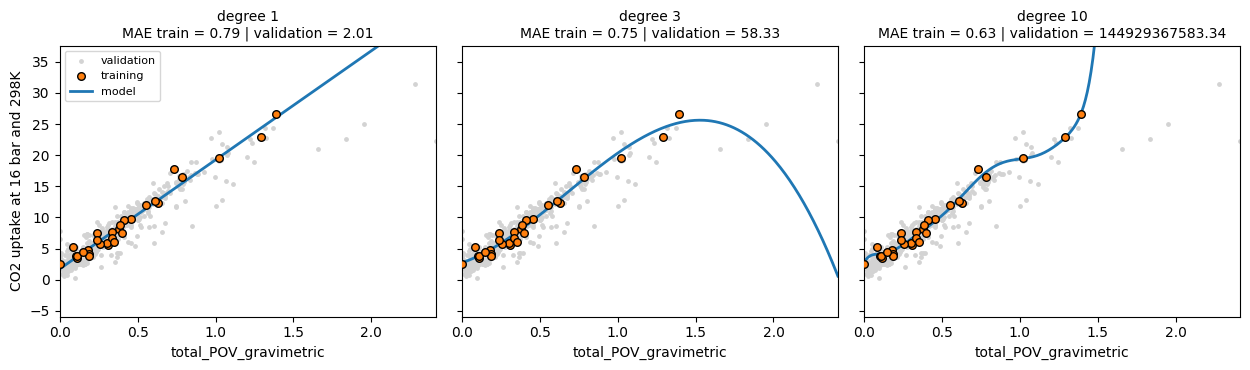

In [93]:
degrees = [1, 3, 10]
poly_models = {}
for degree in degrees:
    model = make_poly_model(degree)
    model.fit(X_small, y_small)
    poly_models[f"degree {degree}"] = model

plot_1d_fits(poly_models)

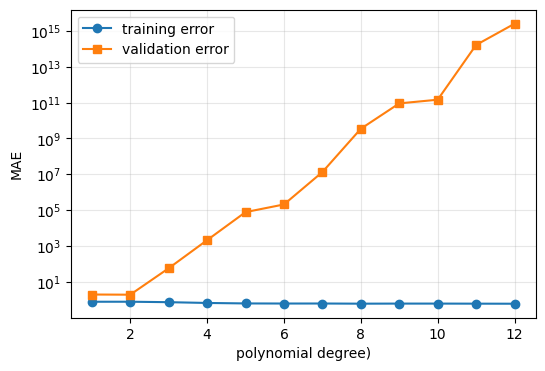

In [94]:
# training and validation error as a function of the polynomial degree
all_degrees = range(1, 13)
mae_train, mae_val = [], []
for degree in all_degrees:
    model = make_poly_model(degree).fit(X_small, y_small)
    mae_train.append(mean_absolute_error(y_small, model.predict(X_small)))
    mae_val.append(mean_absolute_error(y_val_1d, model.predict(X_val_1d)))

plt.figure(figsize=(6, 4))
plt.plot(all_degrees, mae_train, 'o-', label='training error')
plt.plot(all_degrees, mae_val, 's-', label='validation error')
plt.yscale('log')
plt.xlabel('polynomial degree)')
plt.ylabel('MAE')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [95]:
# add code here: number of features after a degree-2 polynomial mapping of all descriptors
d = len(FEATURES)
n_poly = PolynomialFeatures(degree=2, include_bias=False).fit(df_train_stratified[FEATURES]).n_output_features_
print(f"{d} descriptors")
print(f"{n_poly} polynomical features")
print(f"Number of training points: {len(df_train_stratified)}")

138 descriptors
9729 polynomical features
Number of training points: 3999


## 8. Influence of Regularization

In section 7.2, the polynomials memorized the 30 training points (and their noise) and caused overfitting. Regularization reduces this variance by adding a term to the loss function, at the price of some bias.

For ridge regression, `alpha` (in sklearn) controls the strength of the regularization.

### 8.1. Regularization strength

 $\color{Aqua}{\textsf{Short Exercise}}$
-  Fix the polynomial degree to a high value (the highest degree used in section 7.2), train models with different values of `alpha` (between 1e-8 and 100) and compare them using `plot_1d_fits`.
- What happens if you set `alpha` to a really small or to a large value? Why is this the case?

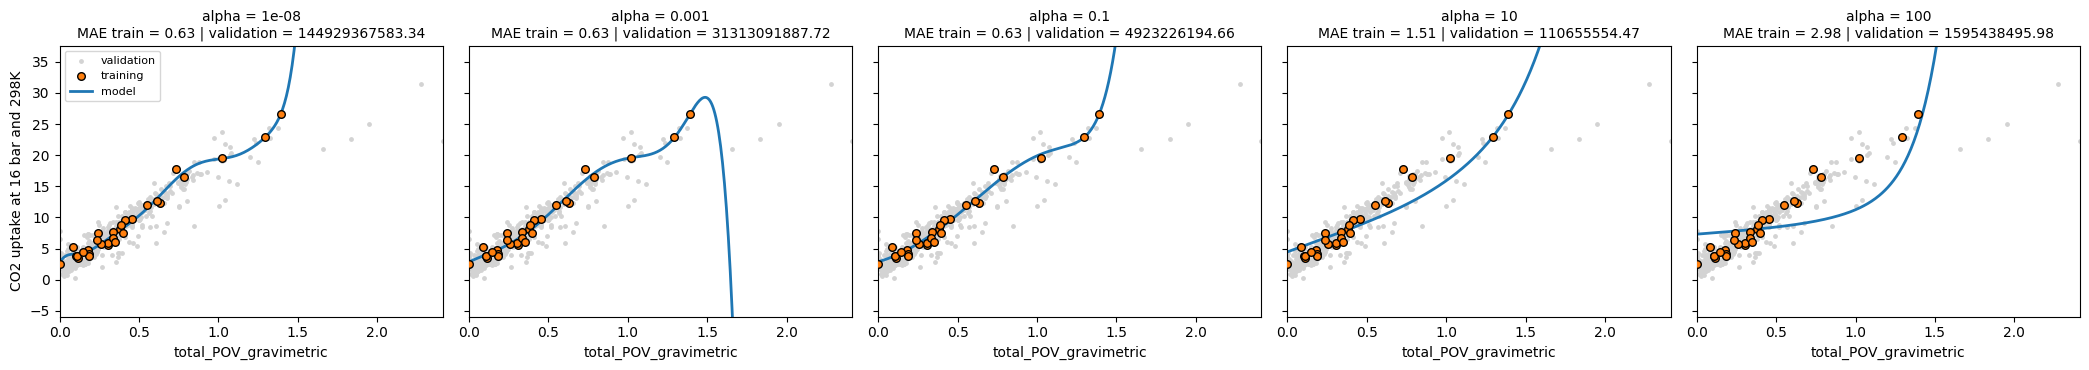

In [96]:
DEGREE = 10
alphas = [1e-8, 1e-3, 1e-1, 10, 100]
ridge_models = {}
for alpha in alphas:
    model = make_poly_model(DEGREE, alpha=alpha)
    model.fit(X_small, y_small)
    ridge_models[f"alpha = {alpha:g}"] = model

plot_1d_fits(ridge_models)

In [97]:
# we can take a look at what happens to the weights as alpha increases
for label, model in ridge_models.items():
    print(f"{label}: ||weights|| = {np.linalg.norm(model['ridge'].coef_)}")

alpha = 1e-08: ||weights|| = 927.9650549180357
alpha = 0.001: ||weights|| = 16.231075452846337
alpha = 0.1: ||weights|| = 7.6043543843204935
alpha = 10: ||weights|| = 3.4381842310605757
alpha = 100: ||weights|| = 1.278821079962782


### 8.2. L2 vs. L1 regularization: Ridge vs. LASSO

Ridge regression shrinks all weights towards zero, but it rarely sets them exactly to zero. If we replace the L2 penalty by the L1 norm, $\lambda\sum_j|\phi_j|$, we get the [`LASSO`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) (Least Absolute Shrinkage and Selection Operator). LASSO sets many weights to exactly zero. Because of this, it can be used for **feature selection**.

$\color{Aqua}{\textsf{Short Exercise}}$
- Build a pipeline `pipe_lasso` with standard scaling and a `Lasso` model (`alpha=0.01`, `max_iter=10000`), fit it and calculate the metrics on the training and test set. How does it compare with the scaled ridge model?
- How many weights are exactly zero in `pipe_lasso` and in `pipe_w_scaling`?
- When would you prefer LASSO over ridge, and vice versa?

In [98]:
pipe_lasso = Pipeline(
   [
       ('scaling', StandardScaler()),
       ('lasso', Lasso(alpha=0.01, max_iter=10000))
   ]
)
pipe_lasso.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])
print("LASSO          - Train:", get_regression_metrics(pipe_lasso, df_train_stratified[FEATURES], df_train_stratified[TARGET]))
print("LASSO          - Test: ", get_regression_metrics(pipe_lasso, df_test_stratified[FEATURES], df_test_stratified[TARGET]))
print("Ridge (scaled) - Test: ", get_regression_metrics(pipe_w_scaling, df_test_stratified[FEATURES], df_test_stratified[TARGET]))

LASSO          - Train: {'mae': 1.0974760422485157, 'mse': 2.597139686787523, 'max_error': 18.410326546049127, 'mape': 0.25144463087629787}
LASSO          - Test:  {'mae': 1.1344750982116734, 'mse': 3.02616937502159, 'max_error': 13.145002584397442, 'mape': 0.23604622172087636}
Ridge (scaled) - Test:  {'mae': 1.479145044089444, 'mse': 127.76625740946814, 'max_error': 353.006100694257, 'mape': 0.28463750319252507}


In [99]:
# add code here: count the weights that are exactly zero (hint: pipeline['lasso'].coef_ == 0)
print(f"LASSO: {(pipe_lasso['lasso'].coef_ == 0).sum()} of {len((pipe_lasso['lasso'].coef_))} weights are exactly zero")
print(f"Ridge: {(pipe_w_scaling['ridge'].coef_ == 0).sum()} of {len((pipe_w_scaling['ridge'].coef_))} weights are exactly zero")

LASSO: 102 of 138 weights are exactly zero
Ridge: 0 of 138 weights are exactly zero


## 9. Hyperparameter Optimization

A key component we did not optimize so far are hyperparameters. Those are parameters of the model that we usually cannot learn from the data but have to fix before we train the model (such as `alpha`).
Since we cannot learn those parameters it is not trivial to select them. Hence, what we typically do in practice is to create another set, a "validation set", and use it to test models trained with different hyperparameters. When the data is limited, a single validation set leads to noisy estimates, so we use k-fold cross-validation.

The most common approach to hyperparameter optimization is to define a grid of all relevant parameters and to search over the grid for the best model performance. We will use [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

### 9.1. Grid search with cross-validation

$\color{Aqua}{\textsf{Short Exercise}}$
- Define a `param_grid` dictionary to change the hyperparameters `alpha` and the scaler.
- For each parameter you need to define a reasonable grid to search over.
- Run the hyperparameter optimization using 5-fold cross-validation.
- Evaluate the model performance by calculating the performance metrics (MAE, MSE, max error) on the training and the test set. 

 $\color{DarkRed}{\textsf{Tips}}$

- For grid search, you need to define a parameter grid, which is a dictionary of the following form:
```(python)
param_grid = {
                    'pipelinestage': [None, TransformerA(), TransformerB()]
                    'pipelinestage__parameter': np.logspace(-4,1,10),
            }
```

- If you want to speed up the optimization, you can run it in parallel by setting the `n_jobs` argument to the number of workers. If you set it to -1 it will use all available cores. Using all cores might freeze your computer if you do not have enough memory.

- If the optimization is too slow, reduce the number of data points in your set, the number of folds or the grid size. 

- After the search, you can access the best model with `.best_estimator_` and the best parameters with `.best_params_` on the GridSearchCV instance. For example `grid_ridge.best_estimator_`

<details>
<summary> <font color='green'>Click here for hints about pipelines and grid search</font></summary>
<ul>
    <li> You can use the <code>np.logspace</code> function to generate a grid for values that you want to vary on a logarithmic scale </li>
    <li> Ridge has one hyperparameter: the regularization strength <code>alpha</code>. For scaled features, values between 1e-3 and 1e3 can be reasonable. </li>
    <li> The scaling step is also a hyperparameter of the pipeline: <code>'scaling': [MinMaxScaler(), StandardScaler()]</code></li>
</ul>
</details>

In [100]:
# Define the parameter grid and the grid search object
param_grid = {
                    'scaling': [MinMaxScaler(), StandardScaler()], # test different scaling methods
                    'ridge__alpha': np.logspace(-3, 3, 13)
            }

grid_ridge = GridSearchCV(pipe_w_scaling, param_grid=param_grid,
                          cv=5, scoring='neg_mean_absolute_error', verbose=1, n_jobs=2)


In [101]:
# run the grid search by calling the fit method
grid_ridge.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])

print("Grid search   best parameters:", grid_ridge.best_params_, f", CV MAE = {-grid_ridge.best_score_}")

Fitting 5 folds for each of 26 candidates, totalling 130 fits
Grid search   best parameters: {'ridge__alpha': 10.0, 'scaling': StandardScaler()} , CV MAE = 1.1338612939700008


Train: {'mae': 1.0641794699719338, 'mse': 2.4227727081764283, 'max_error': 17.405923914862658, 'mape': 0.33906601812424036}
Test:  {'mae': 1.2769376089376296, 'mse': 23.866843952090953, 'max_error': 144.284257012045, 'mape': 0.25948990726153087}


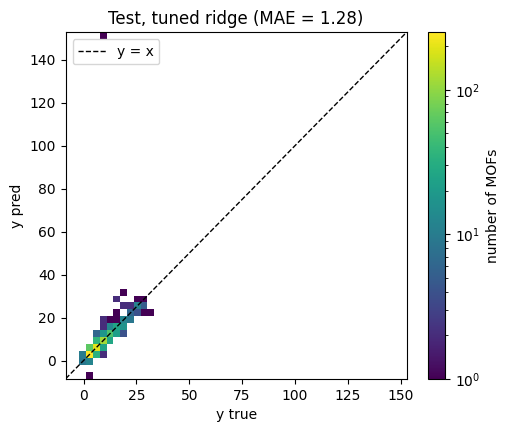

In [102]:
# get the performance metrics
print("Train:", get_regression_metrics(grid_ridge.best_estimator_, df_train_stratified[FEATURES], df_train_stratified[TARGET]))
print("Test: ", get_regression_metrics(grid_ridge.best_estimator_, df_test_stratified[FEATURES], df_test_stratified[TARGET]))
hist_density(df_test_stratified[TARGET], grid_ridge.predict(df_test_stratified[FEATURES]), title='Test, tuned ridge')

<details>
<summary> <font color='green'>Click here for some more information about hyperparameter optimization</font></summary>
Grid search is not the most efficient way to perform hyperparameter optimization. Even <a href="http://jmlr.csail.mit.edu/papers/volume13/bergstra12a/bergstra12a.pdf">random search was shown to be more efficient</a>. Really efficient though are Bayesian optimization approaches like <a href='https://papers.nips.cc/paper/4443-algorithms-for-hyper-parameter-optimization.pdf'>TPE</a>. This is implemented in the hyperopt library, which is also installed in your conda environment.
</details>

## 10. Saving the model

Now, that we spent so much time in optimizing our model, we do not want to lose it.

- use the [joblib library](https://scikit-learn.org/stable/modules/model_persistence.html) to save your model
- make sure you can load it again and that it gives the same predictions

In [103]:
# Dump your model
filename = 'ridge_pipeline.joblib'
model = grid_ridge.best_estimator_
joblib.dump(model, filename)

['ridge_pipeline.joblib']

In [104]:
# Try to load it again
model_loaded = joblib.load(filename)

# check that the loaded model gives the same predictions
np.allclose(model.predict(df_test_stratified[FEATURES]), model_loaded.predict(df_test_stratified[FEATURES]))

True